In [108]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import joblib # Buat simpan model nanti

In [109]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE = '/kaggle/input/datasets/jerismeteo/open-meteo-data-kebumen/open_meteo_climate/jerukagung_75tahun_lengkap.csv'

In [110]:
# ==============================================================================
# 2. LOAD DATA & BERSIHKAN WAKTU
# ==============================================================================
def load_data(filepath):
    print(f"📂 Membaca file: {filepath}")
    if not os.path.exists(filepath):
        print("❌ File tidak ditemukan.")
        return None
    
    # Baca CSV
    df = pd.read_csv(filepath, index_col='date', parse_dates=True)
    
    # Perbaikan Zona Waktu (Agar tidak geser)
    # 1. Baca sebagai UTC
    df.index = pd.to_datetime(df.index, utc=True)
    # 2. Geser ke WIB
    df.index = df.index.tz_convert('Asia/Jakarta')
    # 3. Hapus label zona waktu (biar jadi jam dinding polos)
    df.index = df.index.tz_localize(None)
    
    df = df.sort_index()
    print(f"✅ Data Siap! Rentang: {df.index.min()} s.d {df.index.max()}")
    return df

df = load_data(PATH_FILE)

df.tail(10)

📂 Membaca file: /kaggle/input/datasets/jerismeteo/open-meteo-data-kebumen/open_meteo_climate/jerukagung_75tahun_lengkap.csv
✅ Data Siap! Rentang: 1950-01-01 01:00:00 s.d 2026-02-10 23:00:00


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-02-10 14:00:00,29.65,71.507730,23.95,0.1,13.298089,219.50764,1006.83980,3600.0000,100.0,51.0
2026-02-10 15:00:00,28.75,76.464870,24.20,0.1,14.009968,222.91743,1006.73380,3600.0000,100.0,51.0
2026-02-10 16:00:00,28.50,76.426765,23.95,0.0,12.007498,229.86458,1006.53230,3600.0000,100.0,3.0
2026-02-10 17:00:00,27.95,74.745130,23.05,0.1,11.272657,250.40762,1007.12690,1568.7799,100.0,51.0
2026-02-10 18:00:00,25.05,93.348060,23.90,1.7,7.638875,304.43906,1008.70264,0.0000,100.0,61.0
2026-02-10 19:00:00,25.95,91.457054,24.45,1.1,8.694204,332.90454,1009.00824,0.0000,100.0,55.0
2026-02-10 20:00:00,25.45,93.087800,24.25,0.0,7.100310,329.53452,1009.90280,0.0000,100.0,3.0
2026-02-10 21:00:00,25.45,93.367210,24.30,0.2,5.720489,282.72437,1010.40170,0.0000,100.0,51.0
2026-02-10 22:00:00,25.05,94.760220,24.15,0.1,5.743100,302.19570,1010.59845,0.0000,100.0,51.0


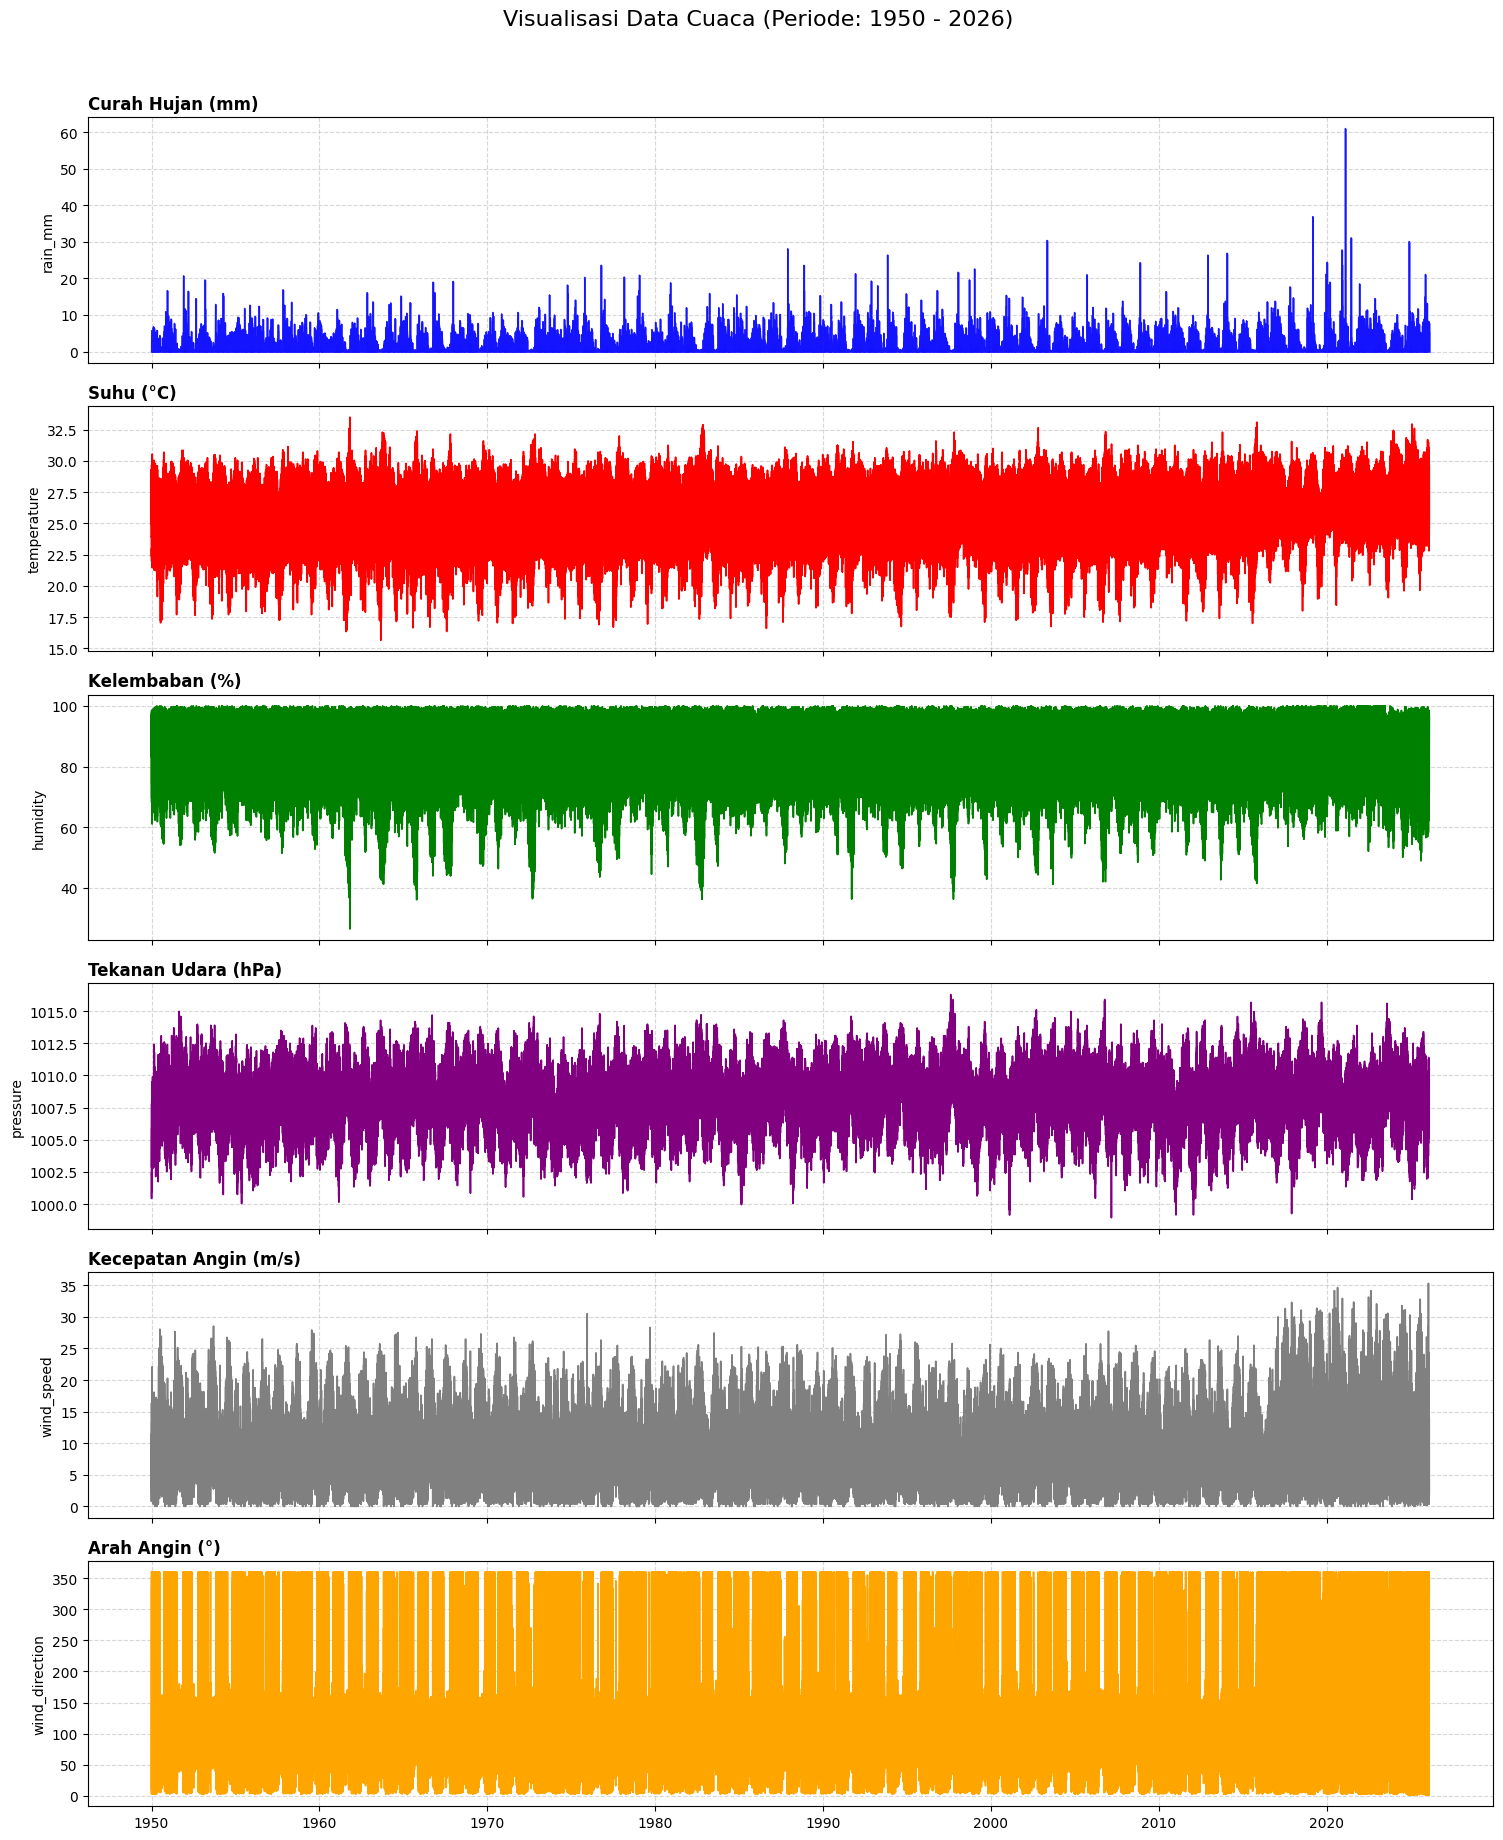

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# VISUALISASI TIME SERIES SEMUA VARIABEL
# =========================================================

# 1. Pilih Kolom yang Mau Di-plot (Otomatis deteksi yang ada)
target_cols = ['rain_mm', 'temperature', 'humidity', 'pressure', 'wind_speed', 'wind_direction']
cols_to_plot = [col for col in target_cols if col in df.columns]

# 2. Atur Ukuran Gambar (Tinggi menyesuaikan jumlah kolom)
n_cols = len(cols_to_plot)
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(15, 3 * n_cols), sharex=True)

# 3. Definisikan Warna & Style biar Cantik
colors = {
    'rain_mm': 'blue',
    'temperature': 'red',
    'humidity': 'green',
    'pressure': 'purple',
    'wind_speed': 'grey',
    'wind_direction': 'orange'
}

titles = {
    'rain_mm': 'Curah Hujan (mm)',
    'temperature': 'Suhu (°C)',
    'humidity': 'Kelembaban (%)',
    'pressure': 'Tekanan Udara (hPa)',
    'wind_speed': 'Kecepatan Angin (m/s)',
    'wind_direction': 'Arah Angin (°)'
}

# 4. Loop untuk Menggambar Setiap Variabel
for i, col in enumerate(cols_to_plot):
    ax = axes[i] if n_cols > 1 else axes # Handle jika cuma 1 kolom
    
    # Ambil data (Bisa di-slice kalau terlalu berat, misal: df.tail(1000))
    data = df[col] 
    
    # Khusus Hujan pakai Area Plot (Biar kelihatan volume-nya)
    if col == 'rain_mm':
        ax.fill_between(data.index, data, color=colors.get(col, 'blue'), alpha=0.6)
        ax.plot(data.index, data, color=colors.get(col, 'blue'), alpha=0.8, linewidth=1)
    else:
        # Yang lain pakai Garis biasa
        ax.plot(data.index, data, color=colors.get(col, 'black'), linewidth=1.2)
    
    # Kosmetik Grafik
    ax.set_title(titles.get(col, col), fontsize=12, loc='left', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel(col)

# Judul Besar
plt.suptitle(f'Visualisasi Data Cuaca (Periode: {df.index.min().year} - {df.index.max().year})', 
             y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

In [112]:
# =========================================================
# 5. PENANGANAN OUTLIER (WINSORIZATION / CAPPING)
# =========================================================

print("\n✂️ MEMULAI PENANGANAN OUTLIER...")

# --- B. UNTUK SUHU & TEKANAN (METODE IQR STANDAR) ---
# Variabel ini biasanya berdistribusi normal, jadi aman pakai IQR.

vars_normal = ['temperature', 'pressure', 'humidity'] # Sesuaikan nama kolommu

for col in vars_normal:
    if col in df.columns:
        # Hitung IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Tentukan Batas Bawah dan Atas
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Khusus Kelembaban, batas atas max 100
        if col == 'humidity': 
            upper_bound = 100
            lower_bound = 40 # Lembab gak mungkin minus
            
        # Hitung jumlah outlier
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) > 0:
            print(f"   -> {col}: Ditemukan {len(outliers)} outlier. (Di-cap ke {lower_bound:.1f} - {upper_bound:.1f})")
            
            # Lakukan Capping
            df.loc[df[col] < lower_bound, col] = lower_bound
            df.loc[df[col] > upper_bound, col] = upper_bound

print("✅ Penanganan Outlier Selesai.")
print(df.describe().T[['min', 'max', 'mean']])


✂️ MEMULAI PENANGANAN OUTLIER...
   -> temperature: Ditemukan 659 outlier. (Di-cap ke 18.3 - 32.1)
   -> pressure: Ditemukan 3871 outlier. (Di-cap ke 1002.8 - 1013.7)
   -> humidity: Ditemukan 53 outlier. (Di-cap ke 40.0 - 100.0)
✅ Penanganan Outlier Selesai.
                           min         max         mean
temperature          18.270000    32.07000    25.133846
humidity             40.000000   100.00000    85.806439
dewpoint             11.345000    27.44500    22.452396
rain_mm               0.000000    61.00000     0.272682
wind_speed            0.000000    35.29561     7.811276
wind_direction        0.895156   360.00000   161.963565
pressure           1002.834650  1013.65905  1008.223241
sunshine_duration     0.000000  3600.00000  1458.995882
cloud_cover           0.000000   100.00000    77.486266
weather_code          0.000000    65.00000    23.767427


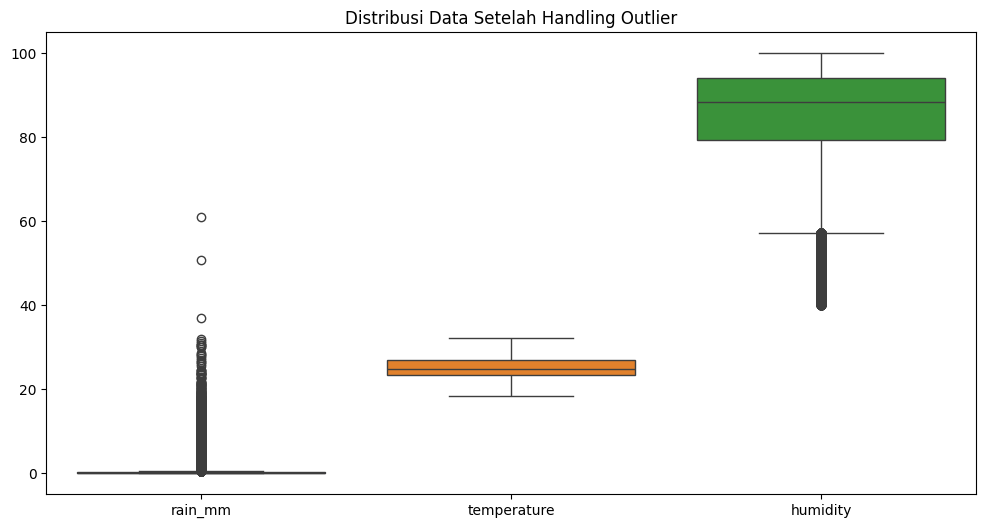

In [113]:
# Gambar Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['rain_mm', 'temperature', 'humidity']])
plt.title("Distribusi Data Setelah Handling Outlier")
plt.show()

In [114]:
# Ambil data 10 tahun terakhir agar relevan dan training tidak terlalu lama
# (Silakan ubah tahunnya jika mau lebih banyak data)
df_ai = df.loc['2000':].copy()

In [115]:
df_ai.tail(10)

,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-02-10 14:00:00,29.65,71.507730,23.95,0.1,13.298089,219.50764,1006.83980,3600.0000,100.0,51.0
2026-02-10 15:00:00,28.75,76.464870,24.20,0.1,14.009968,222.91743,1006.73380,3600.0000,100.0,51.0
2026-02-10 16:00:00,28.50,76.426765,23.95,0.0,12.007498,229.86458,1006.53230,3600.0000,100.0,3.0
2026-02-10 17:00:00,27.95,74.745130,23.05,0.1,11.272657,250.40762,1007.12690,1568.7799,100.0,51.0
2026-02-10 18:00:00,25.05,93.348060,23.90,1.7,7.638875,304.43906,1008.70264,0.0000,100.0,61.0
2026-02-10 19:00:00,25.95,91.457054,24.45,1.1,8.694204,332.90454,1009.00824,0.0000,100.0,55.0
2026-02-10 20:00:00,25.45,93.087800,24.25,0.0,7.100310,329.53452,1009.90280,0.0000,100.0,3.0
2026-02-10 21:00:00,25.45,93.367210,24.30,0.2,5.720489,282.72437,1010.40170,0.0000,100.0,51.0
2026-02-10 22:00:00,25.05,94.760220,24.15,0.1,5.743100,302.19570,1010.59845,0.0000,100.0,51.0


In [116]:
df_ai.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 228912 entries, 2000-01-01 00:00:00 to 2026-02-10 23:00:00
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   temperature        228912 non-null  float64
 1   humidity           228912 non-null  float64
 2   dewpoint           228912 non-null  float64
 3   rain_mm            228912 non-null  float64
 4   wind_speed         228912 non-null  float64
 5   wind_direction     228912 non-null  float64
 6   pressure           228912 non-null  float64
 7   sunshine_duration  228912 non-null  float64
 8   cloud_cover        228912 non-null  float64
 9   weather_code       228912 non-null  float64
dtypes: float64(10)
memory usage: 19.2 MB


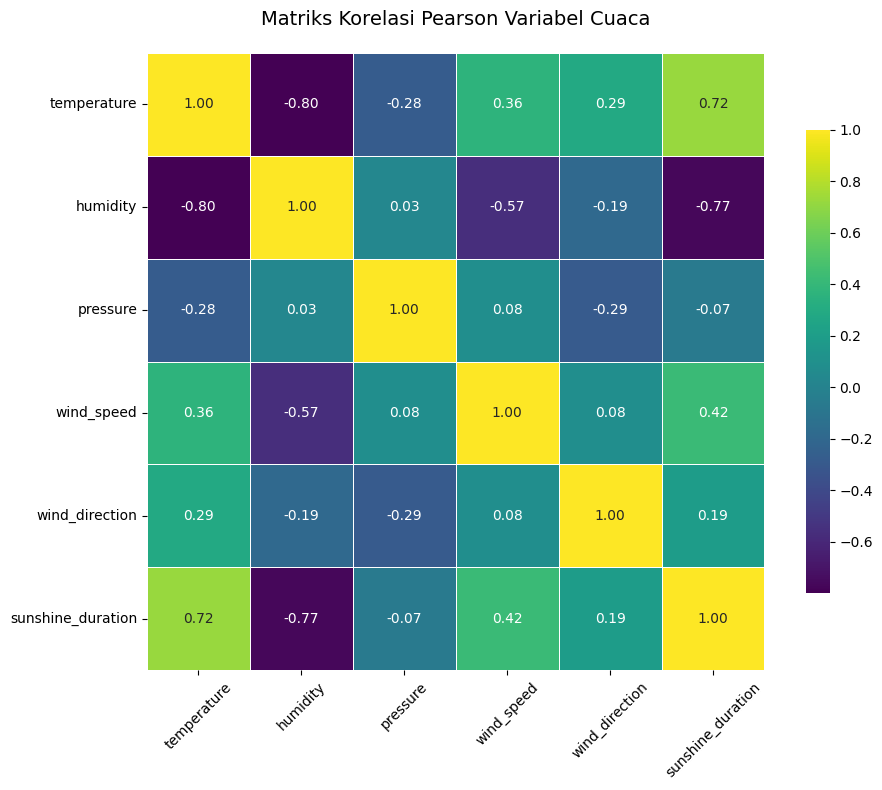

In [125]:
# 1. Pastikan kita pakai data yang sudah bersih (df_ai)
# List fitur yang mau dicek hubungannya
target = 'rain_m'
fitur_analisis = [target, 'temperature', 'humidity', 'pressure', 'wind_speed', 'wind_direction', 'sunshine_duration']

# Filter kolom yang ada aja (biar gak error kalau ada nama beda dikit)
cols_to_plot = [col for col in fitur_analisis if col in df_ai.columns]

# 2. Hitung Matriks Korelasi
# method='pearson' adalah standar untuk hubungan linear
corr_matrix = df_ai[cols_to_plot].corr(method='spearman')

# 3. Plotting Heatmap
plt.figure(figsize=(10, 8))

# Penjelasan Parameter:
# annot=True    : Menampilkan angkanya di dalam kotak
# fmt='.2f'     : Membatasi angka desimal (2 digit di belakang koma)
# cmap='coolwarm': Warna Merah (Positif) ke Biru (Negatif) -> Standar Ilmiah
# vmin=-1, vmax=1: Mengunci skala warna dari -1 sampai 1
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='viridis', 
            linewidths=0.5, 
            square=True,
            cbar_kws={"shrink": 0.75}) # Ukuran color bar

plt.title('Matriks Korelasi Pearson Variabel Cuaca', fontsize=14, pad=20)
plt.xticks(rotation=45) # Miringkan tulisan bawah biar kebaca
plt.yticks(rotation=0)
plt.tight_layout()

# Simpan buat ditaruh di naskah skripsi
plt.savefig('heatmap_korelasi.png', dpi=300) 
plt.show()

In [126]:
# 1. Pilih Fitur
fitur_utama = ['rain_mm','temperature', 'humidity', 'pressure','wind_speed', 'sunshine_duration']
features = [col for col in df_ai.columns if any(x in col for x in fitur_utama)]
target = 'rain_mm'

# 2. Scaling (Wajib)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_ai[features])
y_raw = df_ai[target].values.reshape(-1, 1)
y_scaled = scaler_y.fit_transform(y_raw)

print("✅ Feature Engineering Selesai!")

✅ Feature Engineering Selesai!


In [127]:
# Fungsi Windowing
def create_windows(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 48  # Melihat 24 jam ke belakang

# 1. Buat Window
X_window, y_window = create_windows(X_scaled, y_scaled, TIME_STEPS)

# 2. Split Data
split_idx = int(len(X_window) * 0.80)
X_train, y_train = X_window[:split_idx], y_window[:split_idx]
X_test, y_test = X_window[split_idx:], y_window[split_idx:]

# 3. FLATTENING (Gepengkan Data untuk Ensemble)
# Dari 3D (Sampel, Waktu, Fitur) -> Jadi 2D (Sampel, Waktu*Fitur)
num_train, steps, feats = X_train.shape
num_test, _, _ = X_test.shape

X_train_flat = X_train.reshape(num_train, steps * feats)
X_test_flat = X_test.reshape(num_test, steps * feats)
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

print(f"✅ Siap Training! Data Train: {X_train_flat.shape}")

✅ Siap Training! Data Train: (183091, 288)


In [128]:
import time
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Memulai Training Mode GPU (XGBoost, LightGBM, CatBoost)...")
start_time = time.time()

# --- 1. Definisi Model ---
xgb_gpu = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.005,
    max_depth=10,
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

lgbm_gpu = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.005,
    num_leaves=31,
    device='gpu',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cat_gpu = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.005,
    depth=10,
    task_type="GPU",
    devices='0',
    verbose=0,
    random_state=42
)

# --- 2. Voting Regressor ---
model_gpu = VotingRegressor([
    ('xgb', xgb_gpu),
    ('lgbm', lgbm_gpu),
    ('cat', cat_gpu)
])

# --- 3. Training ---
print("Sedang melatih model... (Tunggu sebentar)")
model_gpu.fit(X_train_flat, y_train_flat)

durasi = time.time() - start_time
print(f"Training selesai dalam {durasi:.2f} detik.")

# ==============================================================================
# EVALUASI PERFORMA MASING-MASING MODEL & ENSEMBLE
# ==============================================================================
print("\n--- LAPORAN EVALUASI MODEL ---")

# Persiapkan data test untuk evaluasi (Reshape untuk scaler)
y_test_reshaped = y_test_flat.reshape(-1, 1)
y_test_real = scaler_y.inverse_transform(y_test_reshaped)

# Daftar model untuk dievaluasi
# model_gpu.estimators_ berisi model yang sudah dilatih di dalam VotingRegressor
daftar_model = [
    ('XGBoost Single', model_gpu.estimators_[0]),
    ('LightGBM Single', model_gpu.estimators_[1]),
    ('CatBoost Single', model_gpu.estimators_[2]),
    ('Ensemble (Voting)', model_gpu)
]

print(f"{'MODEL':<20} | {'MAE (mm)':<10} | {'RMSE (mm)':<10} | {'R2 Score':<10}")
print("-" * 60)

for nama, model in daftar_model:
    # 1. Prediksi
    pred_scaled = model.predict(X_test_flat)
    
    # 2. Kembalikan ke satuan asli
    pred_reshaped = pred_scaled.reshape(-1, 1)
    pred_real = scaler_y.inverse_transform(pred_reshaped)
    
    # 3. Hitung Metrik
    mae = mean_absolute_error(y_test_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    r2 = r2_score(y_test_real, pred_real)
    
    # 4. Tampilkan
    print(f"{nama:<20} | {mae:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}")

print("-" * 60)

Memulai Training Mode GPU (XGBoost, LightGBM, CatBoost)...
Sedang melatih model... (Tunggu sebentar)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:11:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training selesai dalam 100.69 detik.

--- LAPORAN EVALUASI MODEL ---
MODEL                | MAE (mm)   | RMSE (mm)  | R2 Score  
------------------------------------------------------------
XGBoost Single       | 0.2844     | 0.7992     | 0.3637    


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM Single      | 0.2725     | 0.7996     | 0.3630    
CatBoost Single      | 0.2728     | 0.7996     | 0.3629    


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ensemble (Voting)    | 0.2752     | 0.7931     | 0.3733    
------------------------------------------------------------


In [129]:
# ==============================================================================
# LANGKAH PERANTARA: MEMBUAT PREDIKSI (WAJIB DIJALANKAN)
# ==============================================================================

print("⏳ Sedang menghitung prediksi...")

# 1. Lakukan Prediksi (Gunakan 'model_gpu' jika pakai GPU, atau 'model' jika CPU)
# Kita coba deteksi otomatis model mana yang ada
if 'model_gpu' in globals():
    model_aktif = model_gpu
    print("✅ Menggunakan Model GPU")
else:
    model_aktif = model
    print("✅ Menggunakan Model CPU/Standard")

y_pred_scaled = model_aktif.predict(X_test_flat)

# 2. Reshape & Inverse Transform (Kembalikan ke satuan mm asli)
# Scaler butuh input 2D (-1, 1), sedangkan output predict itu 1D
y_pred_reshaped = y_pred_scaled.reshape(-1, 1)
y_test_reshaped = y_test_flat.reshape(-1, 1)

# Kembalikan ke angka curah hujan asli (mm)
y_pred_final = scaler_y.inverse_transform(y_pred_reshaped)
y_test_final = scaler_y.inverse_transform(y_test_reshaped)

# (Opsional) Jika tadi pakai Log Transform, aktifkan baris ini:
# y_pred_final = np.expm1(y_pred_final)
# y_test_final = np.expm1(y_test_final)

print("✅ Variabel 'y_test_final' dan 'y_pred_final' sudah siap!")
print(f"Contoh Prediksi : {y_pred_final[:5].flatten()}")

⏳ Sedang menghitung prediksi...
✅ Menggunakan Model GPU


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Variabel 'y_test_final' dan 'y_pred_final' sudah siap!
Contoh Prediksi : [0.38795355 0.1542269  0.65218968 1.01569215 1.54341307]


🔬 EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)

[1] Ketepatan Angka (Regression Metrics):
   - MAE (Rata-rata Meleset) : 0.275 mm
   - RMSE (Kesalahan Besar)  : 0.793 mm
   - R² (Kecocokan Pola)     : 0.373 (Max 1.0)

[2] Metrik Hidrologi (Scientific):
   - Korelasi Pearson (r)    : 0.612
   - KGE Score               : 0.476
     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)

[3] Kemampuan Deteksi Hujan (Threshold > 1.0 mm):
   - POD (Probability of Detection): 41.62% (Makin tinggi makin jago deteksi hujan)
   - FAR (False Alarm Ratio)       : 51.49% (Makin rendah makin jujur)
   - CSI (Critical Success Index)  : 28.87% (Gabungan)


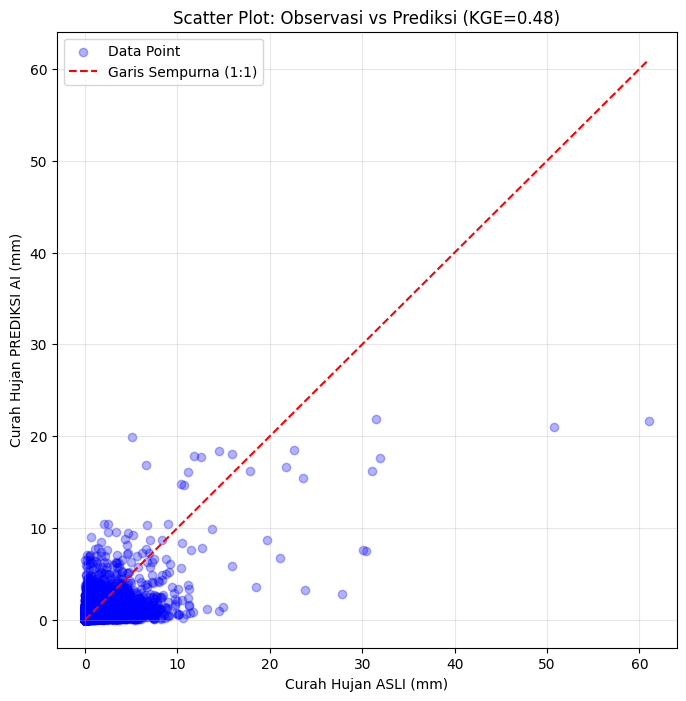

In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

def evaluasi_pro(y_true, y_pred, threshold_hujan=1.0):
    print("="*50)
    print("🔬 EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)")
    print("="*50)

    # --- 1. METRIK REGRESI (STANDAR) ---
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n[1] Ketepatan Angka (Regression Metrics):")
    print(f"   - MAE (Rata-rata Meleset) : {mae:.3f} mm")
    print(f"   - RMSE (Kesalahan Besar)  : {rmse:.3f} mm")
    print(f"   - R² (Kecocokan Pola)     : {r2:.3f} (Max 1.0)")

    # --- 2. METRIK HIDROLOGI (KGE - Kling-Gupta Efficiency) ---
    # Ini "Gold Standard" di penelitian air/hujan.
    # KGE mengukur: Korelasi, Bias, dan Variabilitas sekaligus.
    r_correlation = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r_correlation - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    print(f"\n[2] Metrik Hidrologi (Scientific):")
    print(f"   - Korelasi Pearson (r)    : {r_correlation:.3f}")
    print(f"   - KGE Score               : {kge:.3f}")
    print(f"     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)")

    # --- 3. METRIK DETEKSI (KLASIFIKASI TURUNAN) ---
    # Kita ubah angka jadi status: "Hujan" (>1mm) atau "Tidak" (<1mm)
    # Tujuannya: Cek apakah AI bisa tau KAPAN hujan, meski angkanya meleset dikit.
    y_true_class = (y_true > threshold_hujan).astype(int)
    y_pred_class = (y_pred > threshold_hujan).astype(int)

    print(f"\n[3] Kemampuan Deteksi Hujan (Threshold > {threshold_hujan} mm):")
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
    
    # Metrik Peringatan Dini
    pod = tp / (tp + fn + 1e-10) # Probability of Detection (Sensitivitas)
    far = fp / (fp + tp + 1e-10) # False Alarm Ratio (Sering bohong ga?)
    csi = tp / (tp + fn + fp + 1e-10) # Critical Success Index

    print(f"   - POD (Probability of Detection): {pod:.2%} (Makin tinggi makin jago deteksi hujan)")
    print(f"   - FAR (False Alarm Ratio)       : {far:.2%} (Makin rendah makin jujur)")
    print(f"   - CSI (Critical Success Index)  : {csi:.2%} (Gabungan)")
    
    # --- 4. VISUALISASI SCATTER PLOT ---
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.3, color='blue', label='Data Point')
    
    # Garis Identitas (Target Sempurna)
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Garis Sempurna (1:1)')
    
    plt.title(f"Scatter Plot: Observasi vs Prediksi (KGE={kge:.2f})")
    plt.xlabel("Curah Hujan ASLI (mm)")
    plt.ylabel("Curah Hujan PREDIKSI AI (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- CARA PAKAI ---
# Pastikan y_test_final dan y_pred_final sudah ada dari sel sebelumnya
evaluasi_pro(y_test_final, y_pred_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.28 mm
R2 : 0.3733


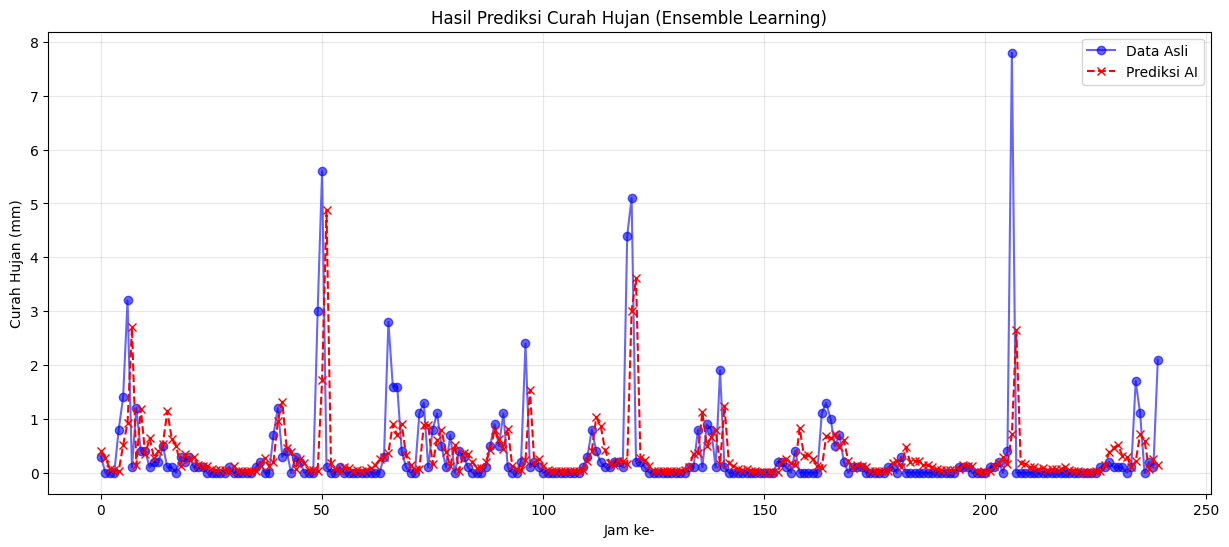

In [131]:
# 1. Prediksi
y_pred_scaled = model_gpu.predict(X_test_flat)

# 2. Kembalikan ke Satuan Asli (mm)
y_pred_final = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_final = scaler_y.inverse_transform(y_test_flat.reshape(-1, 1))

# 3. Hitung Skor
print(f"MAE: {mean_absolute_error(y_test_final, y_pred_final):.2f} mm")
print(f"R2 : {r2_score(y_test_final, y_pred_final):.4f}")

# 4. Gambar Grafik
plt.figure(figsize=(15, 6))
# Zoom in ke 100 jam terakhir biar kelihatan detailnya
plt.plot(y_test_final[-240:], label='Data Asli', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred_final[-240:], label='Prediksi AI', color='red', linestyle='--', marker='x')
plt.title('Hasil Prediksi Curah Hujan (Ensemble Learning)')
plt.ylabel('Curah Hujan (mm)')
plt.xlabel('Jam ke-')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [132]:
# Simpan Model ke File
joblib.dump(model_gpu, 'model_hujan_ensemble.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("💾 Model berhasil disimpan!")

💾 Model berhasil disimpan!
